<a href="https://colab.research.google.com/github/Gautamkhushboo/Machine-Vision-LAB/blob/main/MachineV_4(25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

print("Dataset Path:", path)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.8MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1


In [2]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])      # Show first 5 files
    print("-"*50)

/root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1
[]
--------------------------------------------------
/root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET
[]
--------------------------------------------------
/root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET/validation
[]
--------------------------------------------------
/root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET/validation/images
[]
--------------------------------------------------
/root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET/validation/images/scratches
['scratches_270.jpg', 'scratches_294.jpg', 'scratches_280.jpg', 'scratches_244.jpg', 'scratches_253.jpg']
--------------------------------------------------
/root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET/validati

Total Images: 1800
First Image: /root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET/validation/images/scratches/scratches_270.jpg


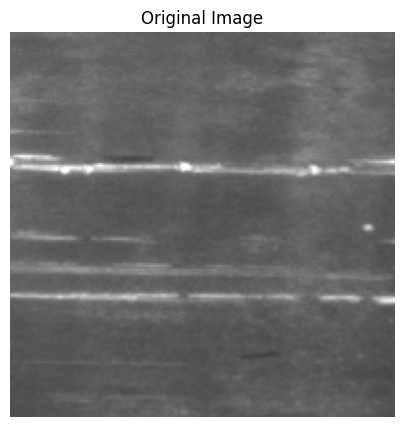

In [3]:
import glob
import cv2
import matplotlib.pyplot as plt

# Find all JPG images
image_paths = glob.glob(path + "/**/*.jpg", recursive=True)

print("Total Images:", len(image_paths))
print("First Image:", image_paths[0])

img = cv2.imread(image_paths[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

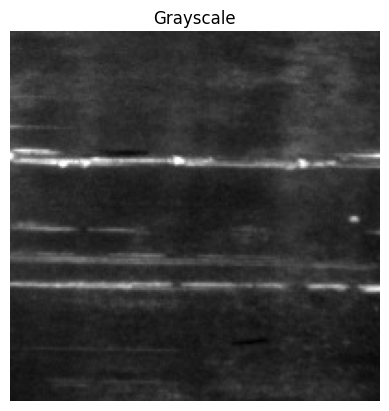

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")
plt.show()

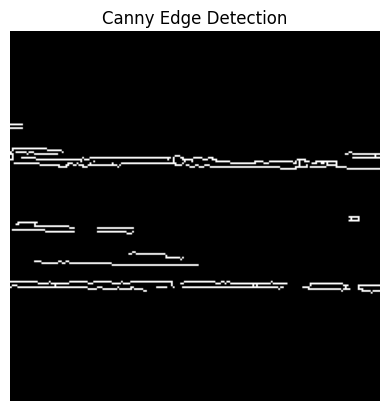

In [6]:
edges = cv2.Canny(gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

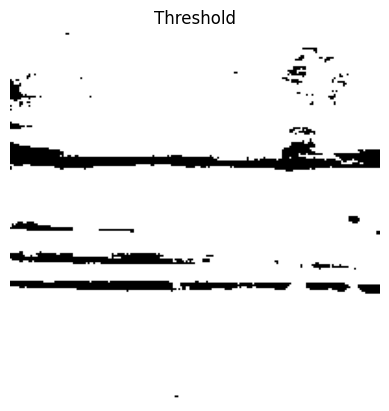

In [7]:
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold")
plt.axis("off")
plt.show()

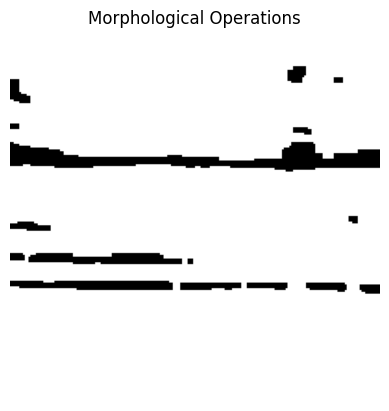

In [8]:
import numpy as np

kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

plt.imshow(closing, cmap='gray')
plt.title("Morphological Operations")
plt.axis("off")
plt.show()

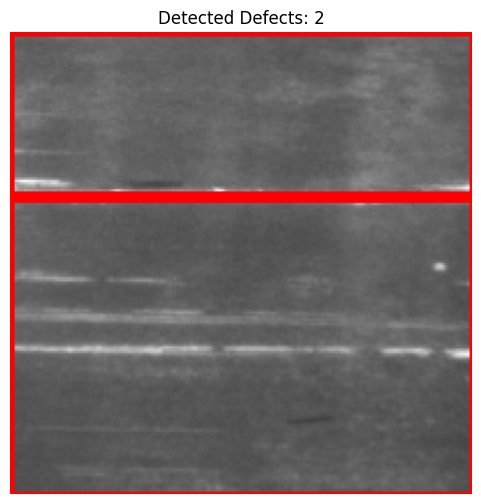

Total Defects: 2


In [9]:
contours, _ = cv2.findContours(closing,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

output = img.copy()

count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 30:
        count += 1
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.figure(figsize=(6,6))
plt.imshow(output)
plt.title(f"Detected Defects: {count}")
plt.axis("off")
plt.show()

print("Total Defects:", count)

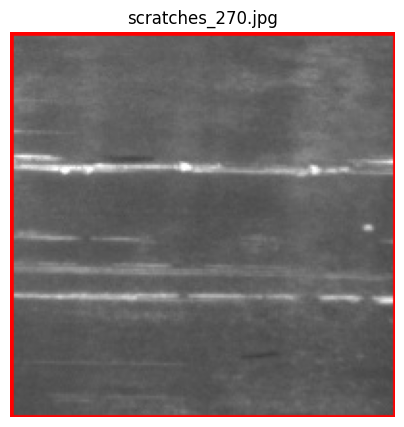

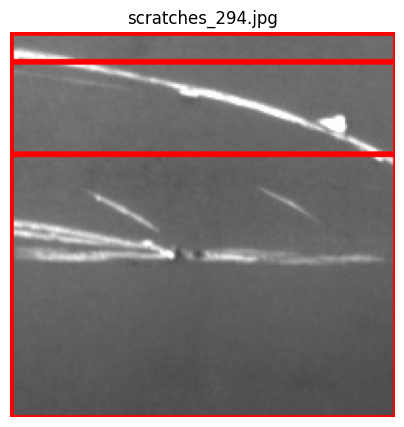

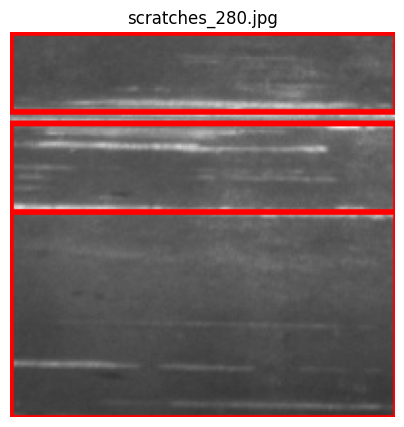

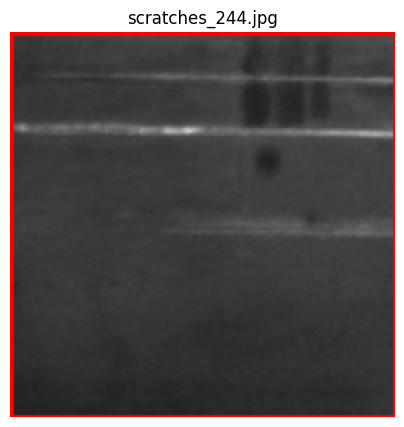

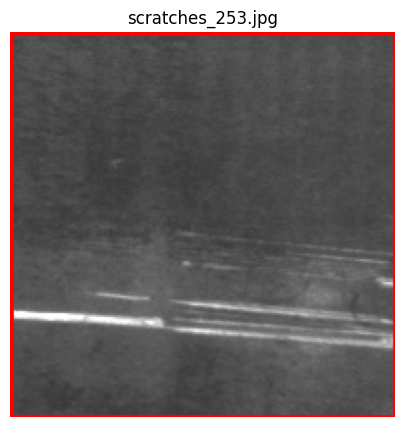

In [10]:
image_paths = glob.glob(path + "/**/*.jpg", recursive=True)

for image_path in image_paths[:5]:   # Process first 5 images
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    _, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((3,3), np.uint8)

    morph = cv2.morphologyEx(thresh,
                             cv2.MORPH_CLOSE,
                             kernel)

    contours, _ = cv2.findContours(morph,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    output = img.copy()

    for cnt in contours:
        if cv2.contourArea(cnt) > 30:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output,
                          (x, y),
                          (x+w, y+h),
                          (255, 0, 0),
                          2)

    plt.figure(figsize=(5,5))
    plt.imshow(output)
    plt.title(os.path.basename(image_path))
    plt.axis("off")
    plt.show()

In [11]:
import kagglehub

path = kagglehub.dataset_download(
    "aniruddhsharma/structural-defects-network-concrete-crack-images"
)

print("Dataset Path:", path)

100%|██████████| 506M/506M [00:15<00:00, 35.0MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1


In [12]:
import os
import glob

# Find all JPG images recursively
image_paths = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)

print("Total Images:", len(image_paths))
print("First 5 Images:")

for img in image_paths[:5]:
    print(img)

Total Images: 56092
First 5 Images:
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls/Cracked/7119-39.jpg
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls/Cracked/7129-247.jpg
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls/Cracked/7076-221.jpg
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls/Cracked/7090-124.jpg
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls/Cracked/7101-189.jpg


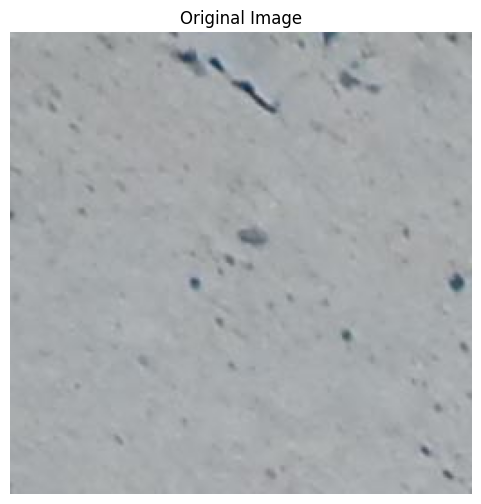

In [13]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[0])

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

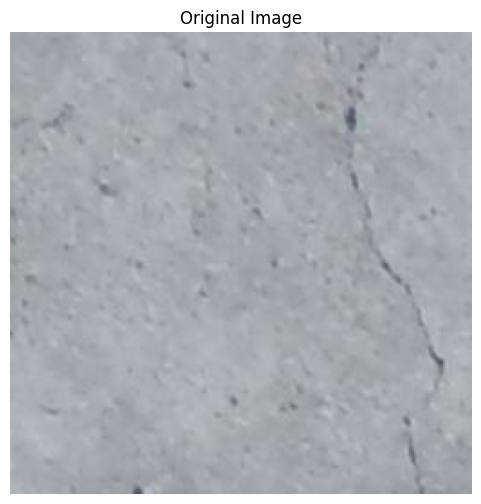

In [14]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[49])   # 50th image

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

Selected Image: /root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls/Non-cracked/7094-35.jpg


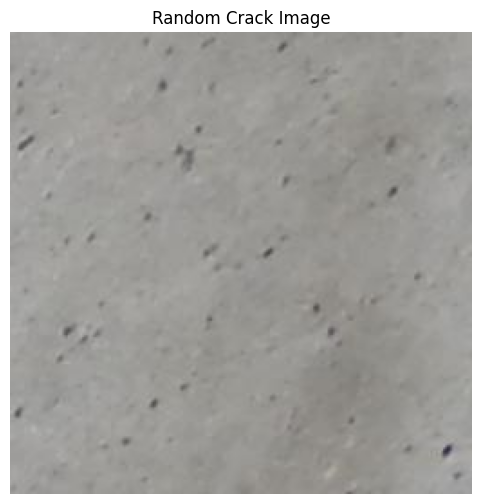

In [15]:
import random
import cv2
import matplotlib.pyplot as plt

random_image = random.choice(image_paths)

print("Selected Image:", random_image)

img = cv2.imread(random_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Random Crack Image")
plt.axis("off")
plt.show()

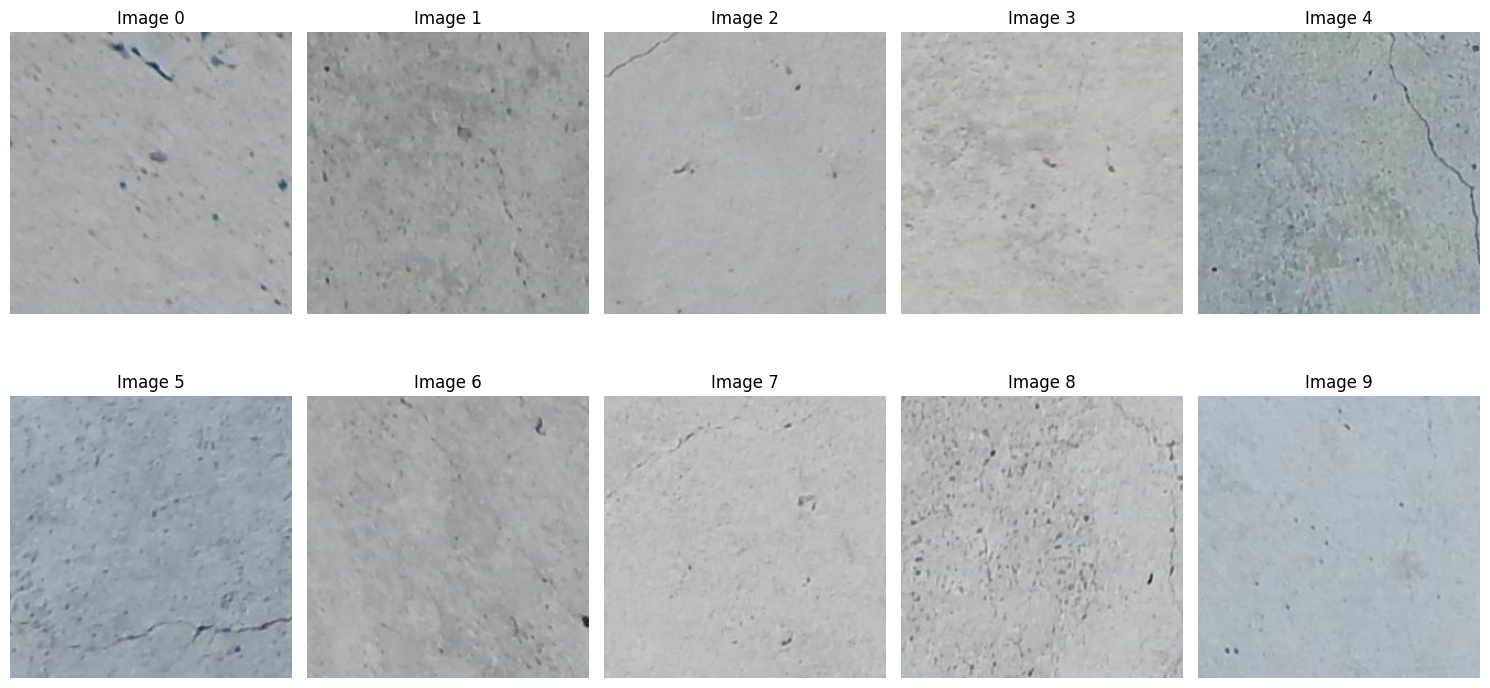

In [17]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

for i in range(10):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()